# Customer churn predictor for an e-commerce businesses

**Problem Statement**

This project proposes a Customer Churn Prediction and Retention Decision Support System for e-commerce businesses. The system will analyse historical customer purchasing behaviour and predict which customers are likely to churn. In addition to making predictions, the system will provide explanations for each prediction and recommend possible retention strategies, such as personalized discounts, loyalty rewards, targeted marketing campaigns, or product recommendations.

**Group 10**

Ewurakua Amoah 74492028  
    Eyram Fenu 31122028  
    Gabriel Akurang 35882028   
    Nana Asantewaa Osei Bonsu 11782028


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os




sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   



file = 'E Commerce Dataset.xlsx'


CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


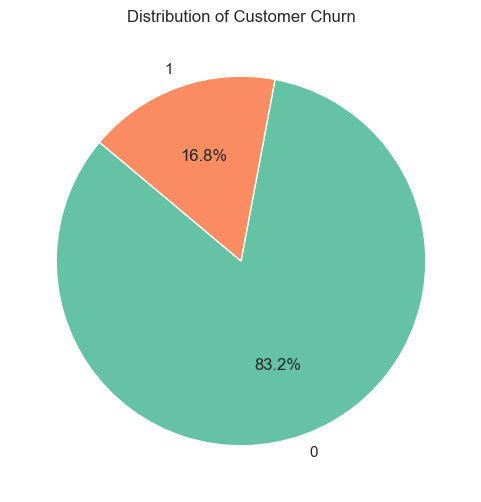

In [2]:
#dataset loaded
e_commerce = pd.read_excel(file, sheet_name="E Comm")

#inspect data
# print(e_commerce.shape)
# print(e_commerce.head())
# print(e_commerce.info())
# print(e_commerce.describe())

# - count missing values per column
print(e_commerce.isna().sum())

#visualize the churn column

churn_counts = e_commerce['Churn'].value_counts()
#print(e_commerce.head())
plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    colors = sns.color_palette('Set2')[0:len(churn_counts)],
    startangle=140
)

plt.title('Distribution of Customer Churn')
plt.show()

# 3. Data Preprocessing

## 3.1 Duplicate Records

Duplicate records occur when the same observation appears more than once in the dataset. If left untreated, duplicate records can bias a machine learning model by giving certain observations more influence than others. Therefore, the dataset is first checked for duplicate entries before proceeding with further preprocessing.

In [3]:
# Check for duplicate rows
duplicate_count = e_commerce.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Observation

The dataset contains **0 duplicate records**, indicating that each customer is represented by a unique observation. Therefore, no duplicate rows were removed, and the dataset can proceed to the next preprocessing stage without modification.

Duplicate records can bias machine learning models by causing certain observations to be overrepresented during training. Since no duplicates were detected, this issue does not affect the current dataset.

## 3.2 Missing Values

Missing values are common in real-world datasets and may arise due to incomplete data collection, human error, or system limitations. Most machine learning algorithms cannot handle missing values directly, making it necessary to identify and treat them before model training.

In this section, the dataset is examined for missing values, after which an appropriate imputation strategy will be selected based on the nature of each variable.

In [4]:
# Count missing values in each column
missing_values = e_commerce.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (missing_values / len(e_commerce)) * 100

# Combine into one table
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display only columns with missing values
missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Percentage (%)
Tenure,264,4.689165
WarehouseToHome,251,4.458259
HourSpendOnApp,255,4.529307
OrderAmountHikeFromlastYear,265,4.706927
CouponUsed,256,4.547069
OrderCount,258,4.582593
DaySinceLastOrder,307,5.452931


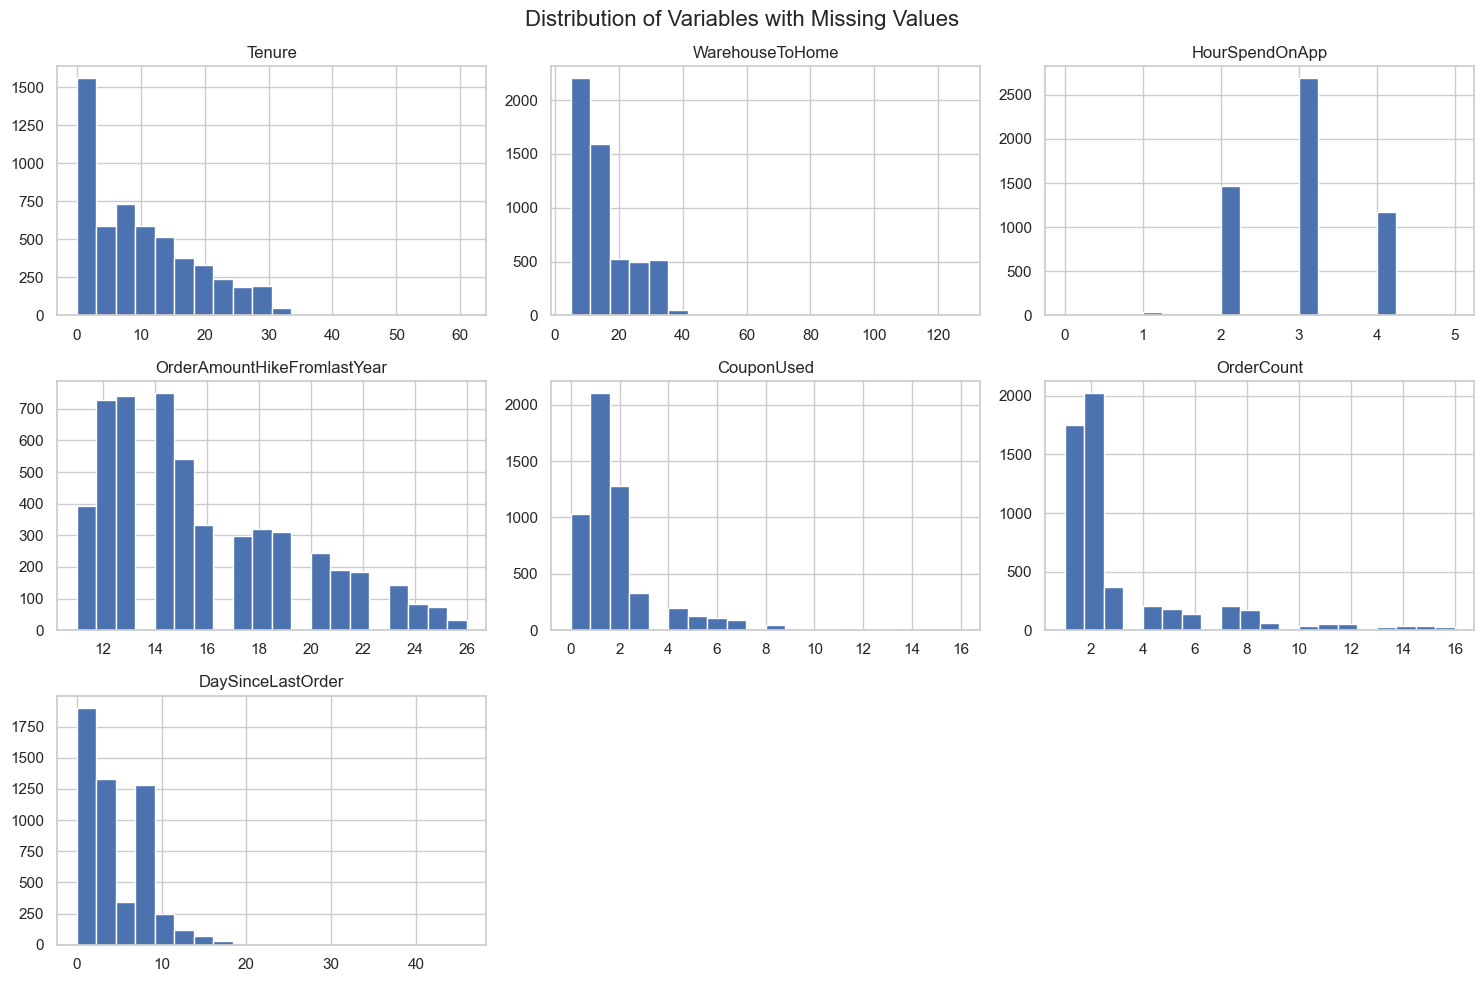

In [5]:
# Visualize the distributions of columns with missing values

columns_with_missing = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder'
]

e_commerce[columns_with_missing].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Variables with Missing Values", fontsize=16)
plt.tight_layout()

plt.show()

In [6]:
# Check skewness

e_commerce[columns_with_missing].skew().sort_values()

HourSpendOnApp                -0.027213
Tenure                         0.736513
OrderAmountHikeFromlastYear    0.790785
DaySinceLastOrder              1.191000
WarehouseToHome                1.619154
OrderCount                     2.196414
CouponUsed                     2.545653
dtype: float64

### Observation

The missing values account for approximately **4–5%** of the dataset across seven numerical variables. Since the proportion of missing data is relatively small, removing these records would unnecessarily reduce the amount of training data available.

To determine the most appropriate imputation method, the distributions and skewness of the affected variables were examined. The results indicate that **HourSpendOnApp** is approximately normally distributed (skewness ≈ -0.03), while the remaining variables exhibit moderate to high positive skewness.

Therefore, the **mean** was used to impute missing values in *HourSpendOnApp*, whereas the **median** was used for all other variables because it is more robust to skewed distributions and outliers.

In [7]:
# Mean imputation for the approximately symmetric variable
e_commerce['HourSpendOnApp'] = e_commerce['HourSpendOnApp'].fillna(
    e_commerce['HourSpendOnApp'].mean()
)

# Median imputation for skewed variables
median_columns = [
    'Tenure',
    'WarehouseToHome',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder'
]

for column in median_columns:
    e_commerce[column] = e_commerce[column].fillna(
        e_commerce[column].median()
    )

In [8]:
# Verify that all missing values have been handled

missing_after = e_commerce.isnull().sum()

print("Total missing values remaining:", missing_after.sum())

missing_after

Total missing values remaining: 0


CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

## 3.3 Data Type Verification

Before training a machine learning model, it is important to verify that every variable has the correct data type. Incorrect data types may lead to unexpected behaviour during preprocessing or model training.

This step confirms that numerical variables are stored as numeric types while categorical variables remain as object types before encoding.

In [9]:
# Display dataset information

e_commerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### Observation

The dataset contains **5,630 observations** and **20 variables**, with no remaining missing values. All variables are stored using appropriate data types. Numerical variables are represented as either integer (`int64`) or floating-point (`float64`) values, while categorical variables are stored as strings.

Since the data types correctly reflect the nature of each variable, no type conversions were required before proceeding to the next preprocessing stage.

## 3.4 Removing Irrelevant Features

Some variables serve only as unique identifiers and do not contain meaningful information for predicting customer churn. Including such variables during model training may introduce unnecessary noise because machine learning algorithms may incorrectly interpret identification numbers as meaningful numerical values.

The `CustomerID` column uniquely identifies each customer but does not describe customer behaviour or purchasing patterns. Therefore, it is removed from the dataset before model development.

In [10]:
# Remove CustomerID since it does not contribute to prediction

e_commerce = e_commerce.drop(columns=['CustomerID'])

print("Remaining columns:", e_commerce.shape[1])

Remaining columns: 19


In [11]:
e_commerce.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

### Observation

The `CustomerID` column was successfully removed because it functions solely as a unique identifier and does not provide meaningful information for predicting customer churn. Removing this feature reduces unnecessary noise and prevents the model from learning relationships based on arbitrary identification numbers.

In [12]:
# Display unique values for all categorical variables

categorical_columns = [
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'Gender',
    'PreferedOrderCat',
    'MaritalStatus'
]

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(e_commerce[column].value_counts())


PreferredLoginDevice
--------------------
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode
--------------------
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender
------
Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat
----------------
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
-------------
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


In [13]:
# Number of unique categories in each categorical feature

for column in categorical_columns:
    print(f"{column}: {e_commerce[column].nunique()} unique values")

PreferredLoginDevice: 3 unique values
PreferredPaymentMode: 7 unique values
Gender: 2 unique values
PreferedOrderCat: 6 unique values
MaritalStatus: 3 unique values


## 3.5 Data Consistency

The `PreferredPaymentMode` column contained abbreviated and full-text versions of the same payment methods. `CC` was treated as `Credit Card`, while `COD` was treated as `Cash on Delivery`.

Standardizing these values prevents the same payment method from being represented as separate categories during one-hot encoding.

In [14]:
# Standardize equivalent payment mode labels
e_commerce['PreferredPaymentMode'] = (
    e_commerce['PreferredPaymentMode']
    .replace({
        'CC': 'Credit Card',
        'COD': 'Cash on Delivery'
    })
)

# Verify the cleaned categories
e_commerce['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

## 3.6 Encoding Categorical Variables

Machine learning algorithms require numerical inputs. Since the categorical variables in this dataset are nominal and have no natural order, one-hot encoding was applied.

The `drop_first=True` option was used to remove one redundant category from each feature and reduce unnecessary duplication.

In [15]:
categorical_columns = [
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'Gender',
    'PreferedOrderCat',
    'MaritalStatus'
]

e_commerce = pd.get_dummies(
    e_commerce,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Dataset shape after encoding:", e_commerce.shape)
e_commerce.head()


Dataset shape after encoding: (5630, 28)


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.000000,3,2,9,1,11.0,1.0,1.0,5.0,159.93,1,0,0,1,0,0,0,0,1,0,0,0,0,1
1,1,9.0,1,8.0,3.000000,4,3,7,1,15.0,0.0,1.0,0.0,120.90,0,1,0,0,0,1,1,0,0,1,0,0,0,1
2,1,9.0,1,30.0,2.000000,4,3,6,1,14.0,0.0,1.0,3.0,120.28,0,1,0,1,0,0,1,0,0,1,0,0,0,1
3,1,0.0,3,15.0,2.000000,4,5,8,0,23.0,0.0,1.0,3.0,134.07,0,1,0,1,0,0,1,0,1,0,0,0,0,1
4,1,0.0,1,12.0,2.931535,3,5,3,0,11.0,1.0,1.0,3.0,129.60,0,1,1,0,0,0,1,0,0,1,0,0,0,1


In [16]:
print("\nRemaining object columns:")
print(e_commerce.select_dtypes(include=['object', 'string']).columns.tolist())


Remaining object columns:
[]


### Observation

All categorical variables were successfully transformed into numerical features using one-hot encoding. The original categorical columns were replaced with binary indicator variables, and no object-type variables remain in the dataset. The dataset is therefore fully numerical and ready for subsequent machine learning preprocessing.

## Preprocessing Summary

The preprocessing stage prepared the dataset for machine learning by addressing data quality and consistency issues.

The following steps were completed:

- Verified that the dataset contained no duplicate records.
- Identified and imputed missing values using appropriate statistical measures.
- Confirmed that all variables had appropriate data types.
- Removed the `CustomerID` identifier as it does not contribute to churn prediction.
- Standardized inconsistent payment method labels.
- Converted all categorical variables into numerical format using one-hot encoding.

Following preprocessing, the dataset contains no missing values, no remaining categorical string variables, and is ready for feature engineering and model development.

# 4. Feature Engineering

## 4.1 Feature Selection

Before creating new features, it is useful to examine how strong the existing variable relate to the "Churn". This gives an early indication of which raw features are likely to be informative and provides a baseline to compare against once new features are added.
 

In [17]:
correlation_with_churn= e_commerce.corr(numeric_only= True)['Churn'].drop('Churn')
correlation_with_churn= correlation_with_churn.sort_values(key=abs, ascending=False)

correlation_with_churn



Tenure                                -0.337831
Complain                               0.250188
MaritalStatus_Single                   0.180847
DaySinceLastOrder                     -0.155871
PreferedOrderCat_Mobile Phone          0.154387
CashbackAmount                        -0.154118
MaritalStatus_Married                 -0.151024
PreferedOrderCat_Laptop & Accessory   -0.133353
PreferedOrderCat_Mobile                0.113364
PreferredLoginDevice_Mobile Phone     -0.111639
NumberOfDeviceRegistered               0.107939
SatisfactionScore                      0.105481
PreferedOrderCat_Grocery              -0.089575
CityTier                               0.084703
PreferredLoginDevice_Phone             0.078916
WarehouseToHome                        0.069544
PreferredPaymentMode_E wallet          0.055751
PreferedOrderCat_Others               -0.054903
PreferredPaymentMode_Credit Card      -0.047728
NumberOfAddress                        0.043931
PreferredPaymentMode_Debit Card       -0

### Observation 
The correlation values give the impression of feature relevance. Variables with very low correlation are not automatically discarded at this stage, since a weak linear correlation does not rule out a non-linear importance. Thus, this step serves as a refernce point before new features are introduced.

# 4.2 Creating New Features 

New features are created to capture behavioural patterens that are not directly repreesented by the raw columns. Each feature is built from raw, unscaled values, since scaling has not yet been appplied to the dataset. None of the new features are derived from 'Churn' so there is not a risk of target leakage.

In [18]:
# Orderd placed per month of tenure
e_commerce['OrderFrequency']= e_commerce['OrderCount'] /(e_commerce['Tenure']+1)

# Share of orders that used coupon
e_commerce['CouponUsageRate'] =e_commerce['CouponUsed'] / (e_commerce['OrderCount'] + 1)

# Days since last order relative to tenure — flags customers who have gone quiet relative to how long they have been a customer, not just in absolute days
e_commerce['RecencyRatio']=e_commerce['DaySinceLastOrder'] /(e_commerce['Tenure'] + 1)

# Engagement score (app usage with no. registered devices) 
e_commerce['EngagementScore'] = (
    e_commerce['HourSpendOnApp'] * e_commerce['NumberOfDeviceRegistered'])

new_features = ['OrderFrequency', 'CouponUsageRate','RecencyRatio','EngagementScore']
e_commerce[new_features].describe()


,OrderFrequency,CouponUsageRate,RecencyRatio,EngagementScore
count,5630.000000,5630.000000,5630.000000,5630.000000
mean,0.568800,0.418112,0.847606,11.036647
std,0.930812,0.316927,1.390631,4.595958
min,0.016393,0.000000,0.000000,0.000000
25%,0.111111,0.250000,0.166667,8.000000
50%,0.250000,0.461538,0.428571,12.000000
75%,0.866667,0.666667,1.000000,15.000000
max,15.000000,4.666667,46.000000,25.000000


### Observation

The 4 features created:

- OrderFrequency — orders per month of tenure
- CouponUsageRate — proportion of orders that used a coupon
- RecencyRatio — days since last order, scaled by tenure
- EngagementScore — app usage combined with device count

Each feature reframes an existing raw variable as a rate rather than a raw count, which is generally more comparable across customers with very different tenures.

## 4.3. Removing Redundant Features

Highly correlated features can introduce multicollinearity, where two variables provide largely the same information. This is checked using a correlation threshold of 0.85, a common rule of thumb, and any candidate pairs are reviewed manually before removal rather than dropped automatically.


In [19]:
import numpy as np

corr_matrix = e_commerce.drop(columns=['Churn']).corr(numeric_only=True).abs()
upper_triangle= corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

redundant_candidates = [
    column for column in upper_triangle.columns if any(upper_triangle[column] > 0.85)
]

print("Feature pairs above 0.85 correlation:")
for column in redundant_candidates:
    high_corr_with = upper_triangle.index[upper_triangle[column] > 0.85].tolist()
    print(f"  {column} <-> {high_corr_with}")

Feature pairs above 0.85 correlation:


## Observation 
No feature pairs exceeded the 0.85 correlation threshold. All 4 engineering features each capture a distinct behavioural signal, so no features were removed here. 

## 4.4 Correlation Analysis 
 A heatmap of all numeric features, including  the newly engineered ones, gives a visual overview of relationships across the full feature set and highlights how the new features relate to Churn compared to the original variables.


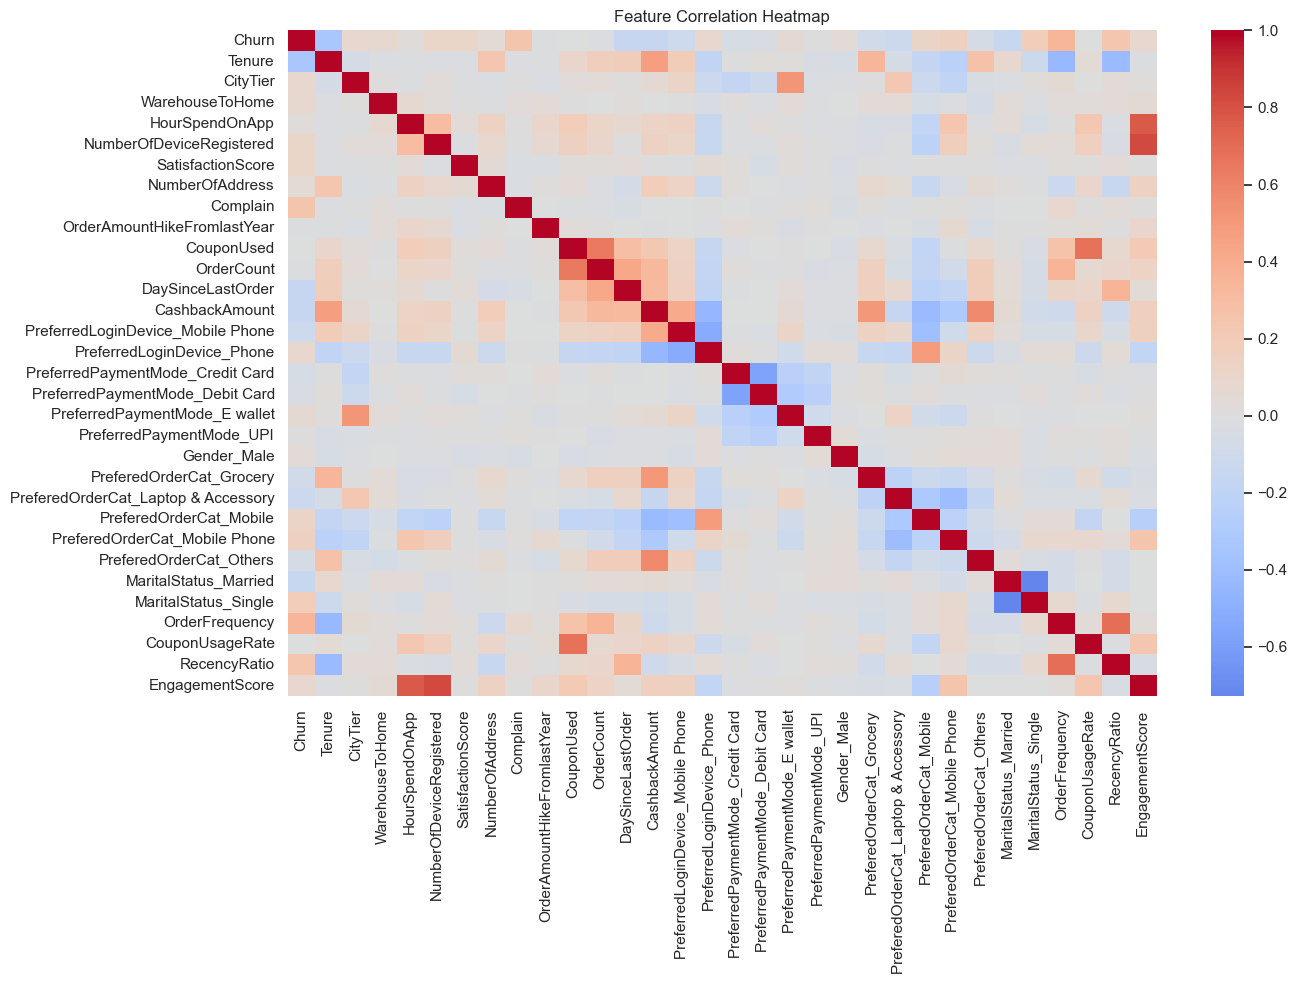

In [24]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    e_commerce.corr(numeric_only=True),
    cmap='coolwarm',
    center=0,
    annot=False
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 4.5 Final Feature Matrix

The dataset is ready to be split into the final feature matrix X and target vector y, now that feature selection, creation, and redundancy checks are complete.Now to hand off for train/test splitting and scaling.

In [ ]:
X= e_commerce.drop(columns= ['Churn'])
Y= e_commerce['Churn']
print("Final feature matrix shape:", X.shape)
print("Number of features:", X.shape[1])
X.head()

Final feature matrix shape: (5630, 31)
Number of features: 31


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,OrderFrequency,CouponUsageRate,RecencyRatio,EngagementScore
0,4.0,3,6.0,3.000000,3,2,9,1,11.0,1.0,1.0,5.0,159.93,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0.2,0.5,1.0,9.000000
1,9.0,1,8.0,3.000000,4,3,7,1,15.0,0.0,1.0,0.0,120.90,0,1,0,0,0,1,1,0,0,1,0,0,0,1,0.1,0.0,0.0,12.000000
2,9.0,1,30.0,2.000000,4,3,6,1,14.0,0.0,1.0,3.0,120.28,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0.1,0.0,0.3,8.000000
3,0.0,3,15.0,2.000000,4,5,8,0,23.0,0.0,1.0,3.0,134.07,0,1,0,1,0,0,1,0,1,0,0,0,0,1,1.0,0.0,3.0,8.000000
4,0.0,1,12.0,2.931535,3,5,3,0,11.0,1.0,1.0,3.0,129.60,0,1,1,0,0,0,1,0,0,1,0,0,0,1,1.0,0.5,3.0,8.794605


## Feature Engineering Summary

This stage is built on the cleaned, encoded dataset from preprocessing by:

- Reviewing correlation of existing features with Churn as a baseline
- Creating four new behavioural features: OrderFrequency, CouponUsageRate, RecencyRatio, and EngagementScore
- Checking for and addressing multicollinearity among numeric features
- Visualizing the full correlation structure of the dataset
- Producing a final feature matrix X and target y for modeling

Now, the dataset is now ready for the modeling team to perform the train/test split and feature scaling.

# 5 Train/test Split and Feature scaling



## 5.1 Train/test Split
In this section, the dataset would be split into two sets:
 - train set -Used mainly for training data
 - Test set- used to check for overfitting or underfitting data.
 - Validation set- Used to tune hyperparameters

To ensure that there are equal proportions in each set we shall use stratify=y, this ensures that the model is not biased towards one type of output or the other.

The dataset will be split in a 60/20/20 split, for train, validation and test sets respectively

In [ ]:
from sklearn.model_selection import train_test_split
X_temp, X_train, y_temp, y_train = train_test_split(#creates a train and a temp
    X, Y, test_size=0.6, random_state=RANDOM_STATE, stratify=Y
)

X_test, X_val, y_test, y_val= train_test_split(#
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)


## Effect
Two sets are initially produced, temp and train sets, though randomly but due to random state can be reproduced over multiple funtion calls or code runs ensuring that the results do not change as we train and rerun the code.
The temp set is them split into validation (tuning hyperparameters) and test set( checking for overfitting)

It is also stratified accordinf to the proportions of the features in Y ensuring that they are proprtional in each set.

## 5.2 Feature scaling

The training set is fit on but both sets are transformed, the test set is not fit as it is used to represent new, unseen data for the model. The StandardScaler takes the mean and standard deviation from the training set and then applies that same scaling to the rest of the data. 

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

numeric_columns=["Tenure",
                "CityTier",
            	"WarehouseToHome",
            	"HourSpendOnApp",
            	"NumberOfDeviceRegistered",
            	"SatisfactionScore",
            	"NumberOfAddress",
            	"Complain",	
                "OrderAmountHikeFromlastYear",	
                "CouponUsed",	
                "OrderCount",	
                "DaySinceLastOrder",	
                "CashbackAmount",		
                "OrderFrequency",
            	"CouponUsageRate",	
                "RecencyRatio",	
                "EngagementScore"]# a set of numeric featurea which would be used for scaling

X_train_scaled=X_train # we must copy the sets into the new scaled model so if in case of an errror we can revert
X_test_scaled=X_test
X_val_scaled=X_val
X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])# the scaling happens only on the numeric columns, binarynot inclusive as that would return the same arrange ment of values
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])
X_val_scaled[numeric_columns] = scaler.transform(X_val[numeric_columns])


## 5.3 Final train/test sets

The dataset is now ready to be used to train the chosen model.

Feature scaling and train/test split are complete

In [ ]:
print(f"Shape of train set: {X_train_scaled.shape}")
print(f"Shape of test set: {X_test_scaled.shape}")
print(f"Shape of validation set: {X_val_scaled.shape}")
print("First 5 rows of train set")
X_train_scaled.head()



Shape of train set: (3378, 31)
Shape of test set: (1126, 31)
Shape of validation set: (1126, 31)
First 5 rows of train set


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,OrderFrequency,CouponUsageRate,RecencyRatio,EngagementScore
3272,0.474317,-0.711028,-0.791063,0.086799,-1.620080,0.684219,-0.466057,-0.648937,2.543613,-0.384991,0.376749,1.011807,-0.204954,0,0,1,0,0,0,0,0,1,0,0,0,0,0,-0.329348,-0.704270,-0.245327,-1.099081
476,0.353411,-0.711028,0.776570,-1.344758,0.301490,-0.044665,1.095014,-0.648937,-0.475668,-0.384991,-0.680862,-1.269063,-0.540866,0,0,1,0,0,0,1,0,1,0,0,0,0,1,-0.552150,0.275934,-0.669624,-0.664483
60,-0.492929,-0.711028,0.535396,-0.011212,-0.659295,0.684219,-0.856325,-0.648937,-0.750148,-0.937454,-0.680862,0.441590,-1.016842,0,1,1,0,0,0,0,0,0,1,0,0,0,0,-0.470637,-1.357739,0.012283,-0.491816
2758,-1.218363,-0.711028,-0.911651,-1.344758,-0.659295,-0.044665,1.095014,1.540982,0.896732,-0.937454,-0.680862,-0.698846,-0.768268,0,1,0,0,0,1,1,0,0,0,1,0,1,0,0.507518,-1.357739,0.921492,-1.099081
3392,-0.734740,1.473468,-0.067540,1.518357,0.301490,-0.044665,1.095014,-0.648937,-1.024628,1.824862,1.786897,1.011807,0.409866,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1.192227,0.457454,0.603269,1.073908


In [ ]:
print("First 5 rows of test set")
X_test_scaled.head()

First 5 rows of test set


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,OrderFrequency,CouponUsageRate,RecencyRatio,EngagementScore
1408,2.408808,1.473468,1.861855,1.518357,-0.659295,1.413104,1.485282,-0.648937,-1.299108,2.377325,1.434360,1.296916,-0.023155,1,0,0,1,0,0,0,0,0,0,0,0,0,1,-0.375977,1.092771,-0.438656,0.204713
4645,-1.097457,-0.711028,-0.308715,1.518357,1.262275,-0.044665,-0.856325,-0.648937,-0.750148,-0.384991,-0.328325,-0.128628,-0.623724,0,1,1,0,0,0,0,0,0,0,1,0,1,0,0.507518,-0.268623,0.921492,1.943104
888,-0.855646,1.473468,-0.308715,0.086799,-0.659295,1.413104,1.485282,-0.648937,-0.475668,-0.384991,-0.680862,-0.698846,-0.604994,0,1,0,0,1,0,0,0,1,0,0,0,1,0,-0.348367,0.275934,-0.271845,-0.447184
711,-1.218363,1.473468,1.620680,-1.344758,0.301490,1.413104,-0.856325,-0.648937,-0.750148,-0.937454,0.024212,1.582025,-0.084433,1,0,0,1,0,0,0,0,0,0,0,0,0,0,2.789880,-1.357739,7.285956,-0.664483
1415,2.408808,1.473468,-1.152825,-1.344758,0.301490,-0.044665,1.485282,-0.648937,-1.299108,-0.384991,-0.680862,-0.413737,-0.463708,0,0,0,1,0,0,0,0,1,0,0,0,0,1,-0.596850,0.275934,-0.592635,-0.664483


In [ ]:
print("First 5 rows of val set")
X_val_scaled.head()

First 5 rows of val set


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,OrderFrequency,CouponUsageRate,RecencyRatio,EngagementScore
5378,0.595223,1.473468,-0.308715,0.086799,0.301490,-0.044665,-0.466057,-0.648937,-0.750148,1.272399,2.139433,-0.413737,0.812349,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0.008252,-0.050800,-0.520457,0.204713
2978,-1.097457,-0.711028,0.897157,0.086799,0.301490,0.684219,-0.075789,1.540982,-0.475668,0.167473,-0.328325,-0.413737,-0.585857,0,1,1,0,0,0,1,0,0,0,1,0,1,0,0.507518,0.820492,0.523713,0.204713
1761,-0.130212,-0.711028,-0.911651,-1.344758,-0.659295,-1.502434,-0.856325,1.540982,1.994653,-0.384991,-0.680862,-1.269063,-1.231418,0,0,0,1,0,0,1,0,0,0,1,0,1,0,-0.519544,0.275934,-0.669624,-1.099081
2671,-1.218363,1.473468,-0.911651,-1.344758,0.301490,0.684219,1.485282,1.540982,-1.024628,-0.384991,-0.328325,-0.698846,0.438978,1,0,0,0,1,0,1,0,1,0,0,0,0,1,1.648699,-0.268623,0.921492,-0.664483
4672,-1.097457,-0.711028,-0.670476,0.086799,1.262275,-1.502434,-0.856325,-0.648937,-0.475668,0.167473,-0.328325,-0.698846,-0.652633,0,1,1,0,0,0,1,0,0,0,1,0,0,1,0.507518,0.820492,0.125934,0.856609


Class distribution for Churn in Train set
Churn
0    0.831557
1    0.168443
Name: proportion, dtype: float64
 
Class distribution for Churn in Test set
Churn
0    0.831261
1    0.168739
Name: proportion, dtype: float64


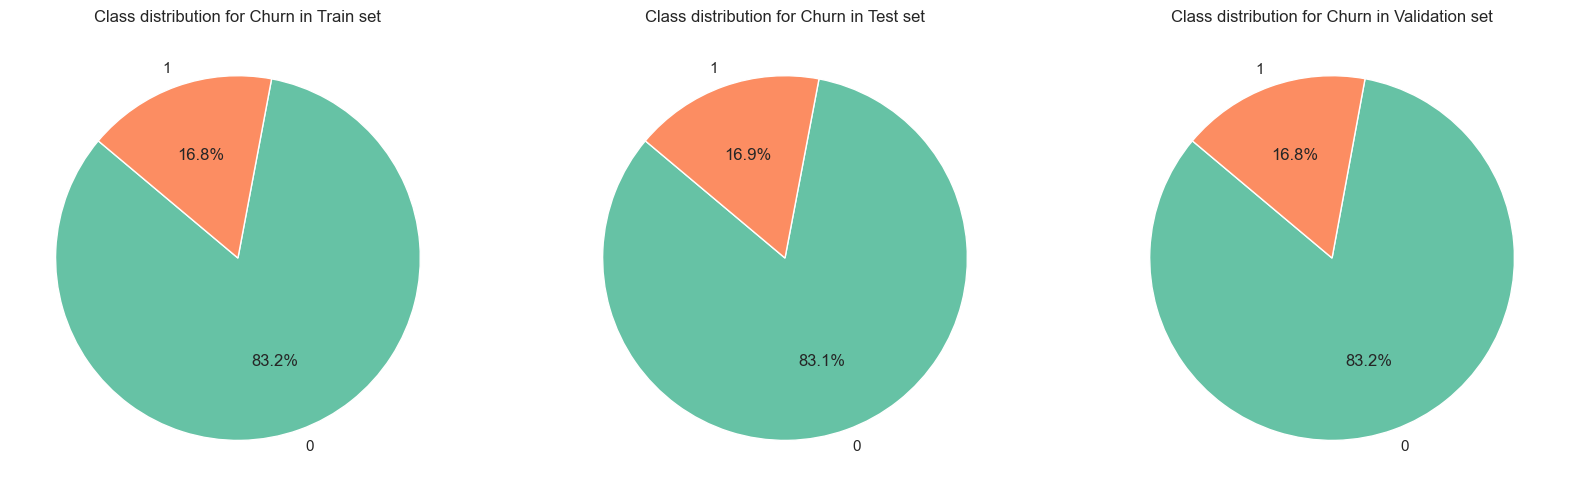

In [ ]:
#prove stratify
print("Class distribution for Churn in Train set")
print(y_train.value_counts(normalize=True))
print(" ")
print("Class distribution for Churn in Test set")
print(y_test.value_counts(normalize=True))
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,10))
ax1.pie(
    y_train.value_counts(), 
    labels=y_train.value_counts().index, 
    autopct='%1.1f%%', 
    colors = sns.color_palette('Set2')[0:len(y_train.value_counts())],
    startangle=140,
    
)
ax1.set_title("Class distribution for Churn in Train set")

ax2.pie(
    y_test.value_counts(), 
    labels=y_test.value_counts().index, 
    autopct='%1.1f%%', 
    colors = sns.color_palette('Set2')[0:len(y_test.value_counts())],
    startangle=140,
    
)
ax2.set_title("Class distribution for Churn in Test set")

ax3.pie(
    y_val.value_counts(), 
    labels=y_val.value_counts().index, 
    autopct='%1.1f%%', 
    colors = sns.color_palette('Set2')[0:len(y_val.value_counts())],
    startangle=140,
    
)
ax3.set_title("Class distribution for Churn in Validation set")

plt.show()

## Train/test split and Feature Engineering summary

After split we realize that now number of rows of traing set is 3378

$$
\implies 0.6 \cdot 5630 = 3378
$$

And number of tuples of the test and validation sets = 1126

$$
\implies 0.4 \cdot 5630 = 2252/2 = 1126
$$

This proves that it is a 60/20/20 split

The Ratios of the classes of the y values of both the validation, test and train sets are equal, and are also equal to that of the origional dataset, hence there will be no case of the model learning only one type of class, reducing overfitting and bias.

Now it is ready to be trained

# 6. Training sample models and compare

## 6.1 KNN - Classifier
This uses information around it to classify unknown values

Pros
- Makes no assumptions on data distribution
- Simple and easy to understand
- It is also easy to update- As it relies on neighbor votes

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test.
y_train_pred= knn.predict(X_train_scaled)
y_train_prob = knn.predict_proba(X_train_scaled)[:, 1]

y_test_pred = knn.predict(X_test_scaled)
y_test_prob = knn.predict_proba(X_test_scaled)[:, 1]



y_val_pred = knn.predict(X_val_scaled)
y_val_prob = knn.predict_proba(X_val_scaled)[:, 1]


In [ ]:
#  Report accuracy AND macro-F1 for ALL THREE sets


accuracy_train=accuracy_score(y_pred=y_train_pred,y_true=y_train)
report_train=classification_report(y_pred=y_train_pred,y_true=y_train)
f1_train=f1_score(y_pred=y_train_pred,y_true=y_train,average="macro")

accuracy_val=accuracy_score(y_pred=y_val_pred,y_true=y_val)
report_val=classification_report(y_pred=y_val_pred,y_true=y_val)
f1_val=f1_score(y_pred=y_val_pred,y_true=y_val,average="macro")

accuracy_test=accuracy_score(y_pred=y_test_pred,y_true=y_test)
report_test=classification_report(y_pred=y_test_pred,y_true=y_test)
f1_test=f1_score(y_pred=y_test_pred,y_true=y_test,average="macro")



print(' ')
print("Train")
print(report_train)
print('F1: ',f1_train)
print('Accuracy: ',accuracy_train)

print(' ')
print("Validation")
print(report_val)
print('F1: ',f1_val)
print('Accuracy: ',accuracy_val)


print("Test")
print(report_test)
print('F1: ',f1_test)
print('Accuracy',accuracy_test)

 
Train
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      2809
           1       0.92      0.69      0.79       569

    accuracy                           0.94      3378
   macro avg       0.93      0.84      0.87      3378
weighted avg       0.94      0.94      0.93      3378

F1:  0.8744784502271817
Accuracy:  0.9369449378330373
 
Validation
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       937
           1       0.78      0.54      0.64       189

    accuracy                           0.90      1126
   macro avg       0.85      0.76      0.79      1126
weighted avg       0.89      0.90      0.89      1126

F1:  0.7910949566912048
Accuracy:  0.8978685612788633
Test
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       936
           1       0.78      0.49      0.60       190

    accuracy                           0.89     

## Observations
The model is overfitting as it has a high accuracy for the train set but lower for validation and test sets.
Its F1 scores are noticably lower than the accuracy scores showing that the model struggles to identify the smaller class in the sets

# 6.2 Logistic Regression - Classifier 

This estimates the probability that a customer belongs to a class by fitting a linear combination of features and passing it through a sigmoid function.

Pros
- This method is imple and fast to train
- It outputs probabilities, not just class labels, which are useful for ranking customers by churn risk
- Coefficients are directly interpretable — each one shows how a feature pushes the prediction towards or away from churn

Cons
- Assumes a roughly linear relationship between features and the log-odds of churn
- Can underperform when the true relationship is more complex or non-linear


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

# To predict on train, validation, and test
y_train_pred= logreg.predict(X_train_scaled)
y_train_prob= logreg.predict_proba(X_train_scaled)[:,1]

y_val_pred = logreg.predict(X_val_scaled)
y_val_prob = logreg.predict_proba(X_val_scaled)[:,1]

y_test_pred=logreg.predict(X_test_scaled)
y_test_prob=logreg.predict_proba(X_test_scaled)[:,1]


In [ ]:
#  Reporting accuracy and macro-F1 for all three sets
accuracy_test =accuracy_score(y_pred=y_test_pred, y_true=y_test)
report_test =classification_report(y_pred=y_test_pred, y_true=y_test)
f1_test= f1_score(y_pred=y_test_pred, y_true=y_test, average="macro")

accuracy_train= accuracy_score(y_pred=y_train_pred, y_true=y_train)
report_train= classification_report(y_pred=y_train_pred, y_true=y_train)
f1_train= f1_score(y_pred=y_train_pred, y_true=y_train, average="macro")

accuracy_val = accuracy_score(y_pred=y_val_pred, y_true=y_val)
report_val = classification_report(y_pred=y_val_pred, y_true=y_val)
f1_val = f1_score(y_pred=y_val_pred, y_true=y_val, average="macro")

print("Test")
print(report_test)
print('F1: ',f1_test)
print('Accuracy',accuracy_test)

print(' ')
print("Train")
print(report_train)
print('F1: ', f1_train)
print('Accuracy: ', accuracy_train)

print(' ')
print("Validation")
print(report_val)
print('F1: ', f1_val)
print('Accuracy: ', accuracy_val)


Test
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       936
           1       0.73      0.53      0.61       190

    accuracy                           0.89      1126
   macro avg       0.82      0.74      0.77      1126
weighted avg       0.88      0.89      0.88      1126

F1:  0.7728233845665038
Accuracy 0.8872113676731794
 
Train
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2809
           1       0.79      0.56      0.65       569

    accuracy                           0.90      3378
   macro avg       0.85      0.76      0.80      3378
weighted avg       0.89      0.90      0.89      3378

F1:  0.7969924047761584
Accuracy:  0.9002368265245707
 
Validation
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       937
           1       0.74      0.58      0.65       189

    accuracy                           0.90      1

## The Confusion Matrix and ROC Curve

The confusion matrix shows exactly where the model gets predictions wrong on the test set, whereas the ROC curve shows how well it separates churners from non-churners across different probability thresholds.


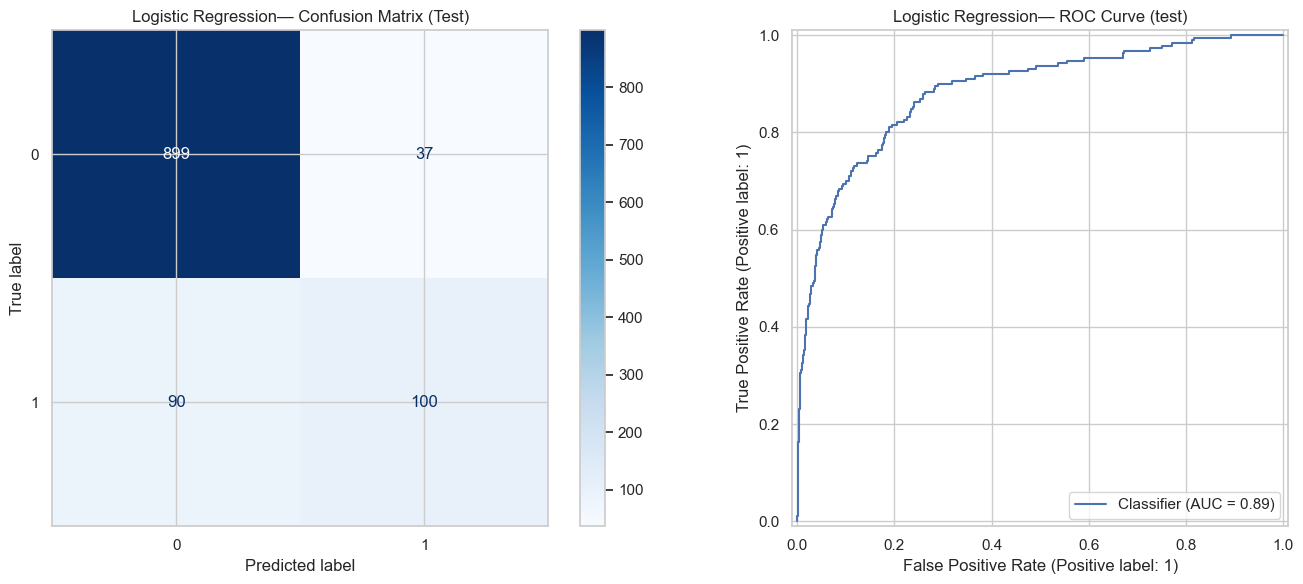

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Blues',ax =axes[0])
axes[0].set_title("Logistic Regression— Confusion Matrix (Test)")

RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[1])
axes[1].set_title("Logistic Regression— ROC Curve (test)")

plt.tight_layout()
plt.show()


## Feature Coefficients

Each coefficient shows how strongly, and in which direction, a feature pushes the model's prediction. Key: Positive coefficients push toward churn, negative coefficients push away from churn.


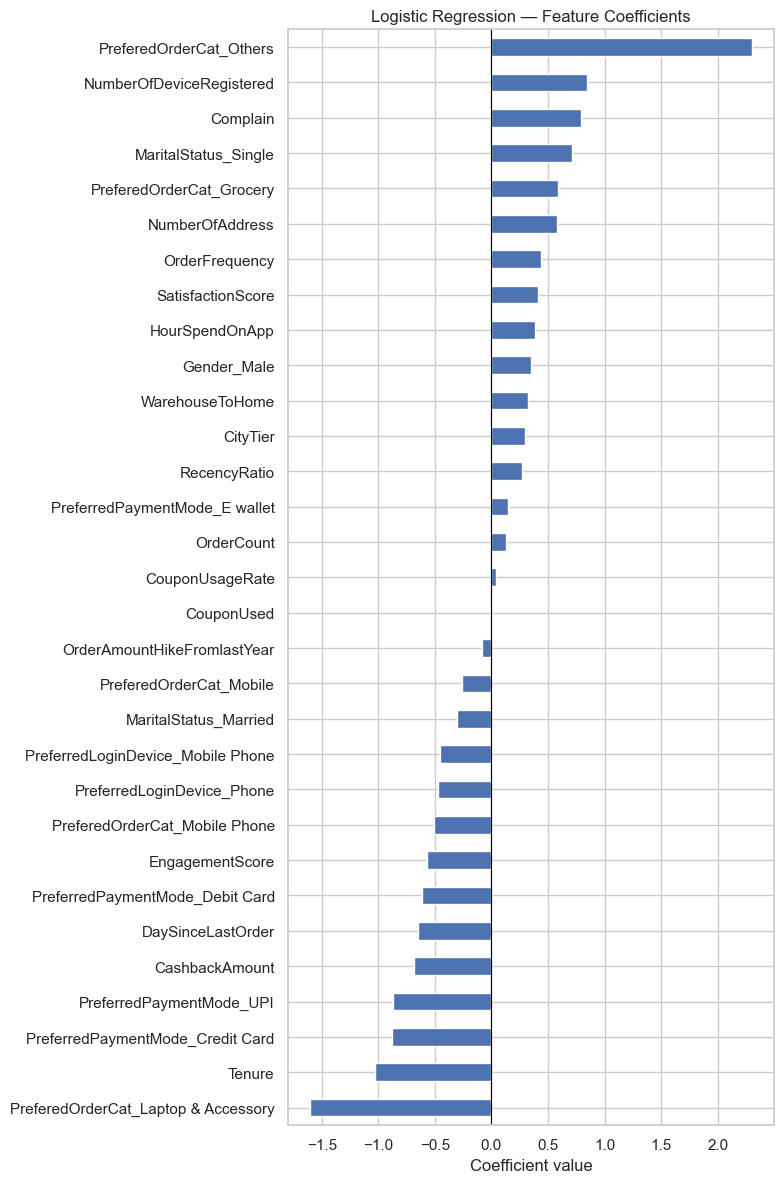

Top 5 positive (push toward churn):
PreferedOrderCat_Others     2.301885
NumberOfDeviceRegistered    0.844594
Complain                    0.794481
MaritalStatus_Single        0.708883
PreferedOrderCat_Grocery    0.589560
dtype: float64

Top 5 negative (push away from chrn):
PreferedOrderCat_Laptop & Accessory   -1.603384
Tenure                                -1.025680
PreferredPaymentMode_Credit Card      -0.883400
PreferredPaymentMode_UPI              -0.866487
CashbackAmount                        -0.684248
dtype: float64


In [ ]:
coefficients = pd.Series(logreg.coef_[0], index=X_train.columns).sort_values()

plt.figure(figsize=(8, 12))
coefficients.plot(kind='barh')
plt.title("Logistic Regression — Feature Coefficients")
plt.xlabel("Coefficient value")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 5 positive (push toward churn):")
print(coefficients.sort_values(ascending=False).head(5))
print()
print("Top 5 negative (push away from chrn):")
print(coefficients.sort_values().head(5))

# Observation:
Logistic Regression's test accuracy stayed close to its train and validation scores, which suggests it generalizes well without overfitting much. It still struggles somewhat with the minority churn class. The strongest predictors pushing customers toward churn were filing a complaint, having more registered devices, and ordering in the "Others" category, while longer tenure, paying by credit card, and ordering "Laptop & Accessory" items were the strongest factors pushing against churn.

## 6.3 Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting. Each tree is trained using a random sample of the training data and a random subset of features, while the final classification is determined through majority voting.

Although Random Forest does not require feature scaling, the scaled datasets are used here to remain consistent with the other models in the project.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predictions
y_train_pred = rf_model.predict(X_train_scaled)
y_val_pred = rf_model.predict(X_val_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

In [ ]:
# Report accuracy and macro-F1 for all three sets

# Test set
rf_accuracy_test = accuracy_score(
    y_true=y_test,
    y_pred=y_test_pred
)

rf_report_test = classification_report(
    y_true=y_test,
    y_pred=y_test_pred
)

rf_f1_test = f1_score(
    y_true=y_test,
    y_pred=y_test_pred,
    average="macro"
)

# Training set
rf_accuracy_train = accuracy_score(
    y_true=y_train,
    y_pred=y_train_pred
)

rf_report_train = classification_report(
    y_true=y_train,
    y_pred=y_train_pred
)

rf_f1_train = f1_score(
    y_true=y_train,
    y_pred=y_train_pred,
    average="macro"
)

# Validation set
rf_accuracy_val = accuracy_score(
    y_true=y_val,
    y_pred=y_val_pred
)

rf_report_val = classification_report(
    y_true=y_val,
    y_pred=y_val_pred
)

rf_f1_val = f1_score(
    y_true=y_val,
    y_pred=y_val_pred,
    average="macro"
)

print("Test")
print(rf_report_test)
print("F1:", rf_f1_test)
print("Accuracy:", rf_accuracy_test)

print("\nTrain")
print(rf_report_train)
print("F1:", rf_f1_train)
print("Accuracy:", rf_accuracy_train)

print("\nValidation")
print(rf_report_val)
print("F1:", rf_f1_val)
print("Accuracy:", rf_accuracy_val)

Test
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       936
           1       0.92      0.69      0.79       190

    accuracy                           0.94      1126
   macro avg       0.93      0.84      0.87      1126
weighted avg       0.94      0.94      0.93      1126

F1: 0.8748941750505065
Accuracy: 0.9369449378330373

Train
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2809
           1       1.00      1.00      1.00       569

    accuracy                           1.00      3378
   macro avg       1.00      1.00      1.00      3378
weighted avg       1.00      1.00      1.00      3378

F1: 1.0
Accuracy: 1.0

Validation
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       937
           1       0.90      0.75      0.82       189

    accuracy                           0.94      1126
   macro avg       0.93      0

In [ ]:
# Create a DataFrame of feature importances

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 most important features
feature_importance.head(10)

,Feature,Importance
0,Tenure,0.135873
27,OrderFrequency,0.113706
12,CashbackAmount,0.079074
29,RecencyRatio,0.071273
2,WarehouseToHome,0.056229
6,NumberOfAddress,0.056001
11,DaySinceLastOrder,0.052226
7,Complain,0.048684
8,OrderAmountHikeFromlastYear,0.045212
5,SatisfactionScore,0.037612


### Observation

The feature importance plot identifies the variables that contributed most to the Random Forest classifier's predictions. Features with higher importance scores had a greater influence on determining whether a customer churned or remained with the company.

These results provide useful business insights by highlighting the customer characteristics and behaviours that are most associated with churn. Such information can help the company prioritise customer retention strategies around the most influential factors.

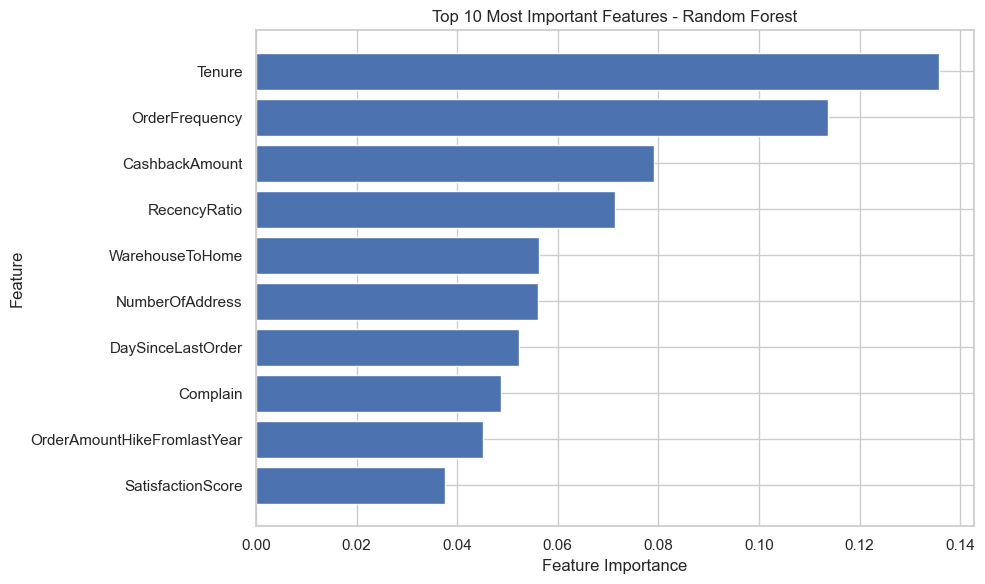

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10][::-1],
    feature_importance["Importance"][:10][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - Random Forest")

plt.tight_layout()
plt.show()

### Interpretation of Feature Importance

The Random Forest model identified **Tenure** as the most influential feature for predicting customer churn. This suggests that the length of time a customer has remained with the company plays a significant role in determining whether they are likely to churn.

The second most important feature was **OrderFrequency**, indicating that customers who purchase more frequently tend to exhibit different churn behaviour compared to less active customers.

Other important predictors include **CashbackAmount**, **RecencyRatio**, **WarehouseToHome**, **NumberOfAddress**, and **DaySinceLastOrder**, suggesting that purchasing behaviour, customer engagement, accessibility, and recency of activity all contribute to churn prediction.

Interestingly, **Complain**, **OrderAmountHikeFromlastYear**, and **SatisfactionScore** also contributed to the model, although their relative importance was lower than the leading features.

Overall, the feature importance analysis indicates that customer loyalty, purchasing behaviour, and engagement are the strongest drivers of churn within this dataset.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


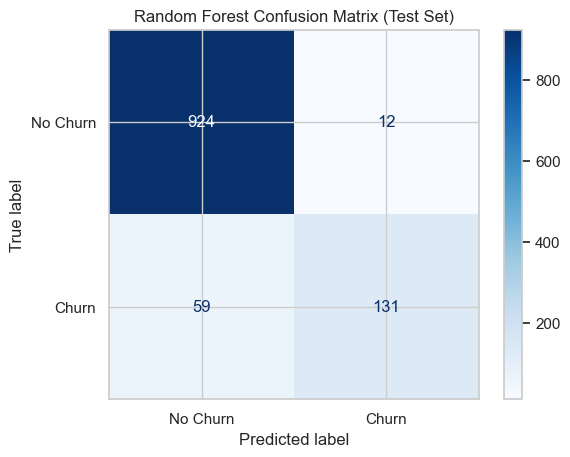

In [ ]:
# Confusion Matrix - Test Set

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix (Test Set)")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the Random Forest classifier performed well on the test dataset.

The model correctly classified **924** customers who did not churn and successfully identified **131** customers who churned. It incorrectly predicted churn for **12** non-churning customers (false positives) and failed to identify **59** customers who actually churned (false negatives).

The relatively low number of false positives indicates that the model is reliable when predicting customer churn. However, the higher number of false negatives suggests that some churning customers remain undetected. Overall, the confusion matrix supports the high accuracy and F1-score achieved by the Random Forest model while highlighting opportunities to improve recall for the churn class.

## 6.4 Support Vector Machine - Classifier
It makes use of a hyperplane to separate different classes in the data.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

svm_model = SVC(kernel="linear", C=1, random_state= RANDOM_STATE)

svm_model.fit(X_train_scaled, y_train)

y_test_pred = svm_model.predict(X_test_scaled)
y_train_pred = svm_model.predict(X_train_scaled)
y_val_pred = svm_model.predict(X_val_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)


In [ ]:
#  Reporting accuracy and macro-F1 for all three sets
accuracy_test =accuracy_score(y_pred=y_test_pred, y_true=y_test)
report_test =classification_report(y_pred=y_test_pred, y_true=y_test)
f1_test= f1_score(y_pred=y_test_pred, y_true=y_test, average="macro")

accuracy_train= accuracy_score(y_pred=y_train_pred, y_true=y_train)
report_train= classification_report(y_pred=y_train_pred, y_true=y_train)
f1_train= f1_score(y_pred=y_train_pred, y_true=y_train, average="macro")

accuracy_val = accuracy_score(y_pred=y_val_pred, y_true=y_val)
report_val = classification_report(y_pred=y_val_pred, y_true=y_val)
f1_val = f1_score(y_pred=y_val_pred, y_true=y_val, average="macro")

print("Test")
print(report_test)
print('F1: ',f1_test)
print('Accuracy',accuracy_test)

print(' ')
print("Train")
print(report_train)
print('F1: ', f1_train)
print('Accuracy: ', accuracy_train)

print(' ')
print("Validation")
print(report_val)
print('F1: ', f1_val)
print('Accuracy: ', accuracy_val)

Test
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       936
           1       0.74      0.49      0.59       190

    accuracy                           0.89      1126
   macro avg       0.82      0.73      0.76      1126
weighted avg       0.88      0.89      0.88      1126

F1:  0.7631966351209254
Accuracy 0.8854351687388987
 
Train
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2809
           1       0.80      0.56      0.66       569

    accuracy                           0.90      3378
   macro avg       0.86      0.77      0.80      3378
weighted avg       0.90      0.90      0.90      3378

F1:  0.8018115761761309
Accuracy:  0.9026050917702783
 
Validation
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       937
           1       0.75      0.57      0.65       189

    accuracy                           0.90      1

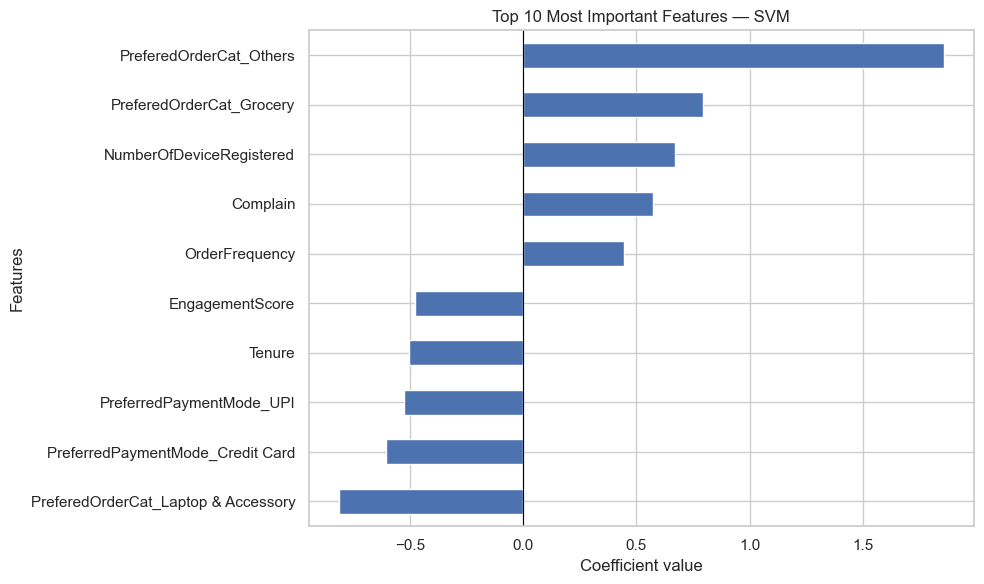

Top 5 positive features:
PreferedOrderCat_Others     1.859044
PreferedOrderCat_Grocery    0.796044
NumberOfDeviceRegistered    0.669587
Complain                    0.574232
OrderFrequency              0.443771
dtype: float64

Top 5 negative features:
PreferedOrderCat_Laptop & Accessory   -0.816503
PreferredPaymentMode_Credit Card      -0.609602
PreferredPaymentMode_UPI              -0.527860
Tenure                                -0.506082
EngagementScore                       -0.477197
dtype: float64


In [ ]:

# coefficients with feature names
svm_coefficients = pd.Series(svm_model.coef_[0], index=X_train.columns)

#  Sorted by their absolute values
top_10_features = svm_coefficients.reindex(
    svm_coefficients.abs().sort_values(ascending=False).head(10).index
)

top_10_features = top_10_features.sort_values(ascending=True)


plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh')
plt.title("Top 10 Most Important Features — SVM")
plt.xlabel("Coefficient value")
plt.ylabel("Features")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()



print("Top 5 positive features:")
print(top_10_features.sort_values(ascending=False).head(5))
print("\nTop 5 negative features:")
print(top_10_features.head(5))

Based on the SVM feature graph, the feature with the highest risk factor is PreferedOrderCat_Others with a value of 1.856. This means that customers whose favorite
order category falls under "Others" are highly likely to churn. Other features that push towards churn include PreferedOrderCat_Grocery, NumberOfDeviceRegistered, 
Complain and OrderFrequency.

Customers buying laptop and accessory are highly stable and unlikely to leave. Customers who prefer paying with "Credit Card" or "UPI" are also less likely to churn compared to other unlisted payment options. Other features that push toward no churn include Tenure and EngagementScore .

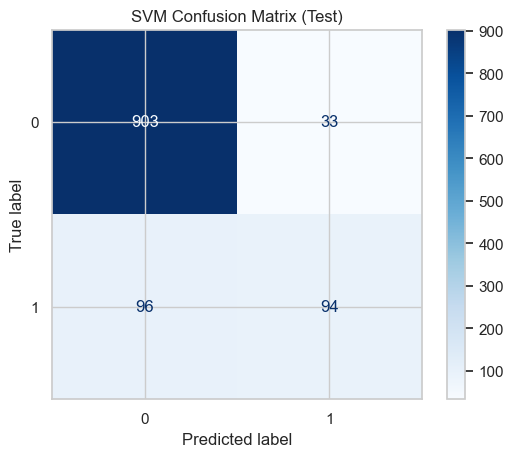

In [ ]:
#confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Blues')
plt.title("SVM Confusion Matrix (Test)")


plt.show()

True Negatives = 903
True Positives = 94
False Negatives = 96
False Positives = 33

The model correctly predicts the outcome for roughly 88.5% of all test cases. When the model indicates a customer as a churn risk, it is correct about 74% of the time. 
The model only catches about 49.5% of the total actual churners. It misses more than half of the customers who are actually leaving. The model haas a low recall rate for churn.

In [ ]:
import joblib
filename='randomforest.pkl'
joblib.dump(rf_model, open(filename,'wb'))

# 7. Evaluation of System Performance

Section 6 trained four models and printed a report for each one separately. This
section brings them together so they can be compared directly, and explains which
metric we trust and why.

Accuracy is not enough her so we report:

| Metric | Meaning | Why it matters here |
|---|---|---|
| **Accuracy** | Overall % correct | Easy to read, but inflated by the imbalance |
| **Precision** (churn) | Of those we flagged, how many really churned | High precision = we don't waste discounts |
| **Recall** (churn) | Of those who really churned, how many we caught | **Our key metric** — a missed churner is a lost customer |
| **Macro-F1** | F1 averaged equally over both classes | Cannot be gamed by the majority class |
| **ROC-AUC** | Ranking quality, independent of threshold | Best single summary for imbalanced data |

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

models = {
    "KNN (k=5)":  knn,
    "Logistic Regression": logreg,
    "Random Forest": rf_model,
    "SVM (linear)":  svm_model,
}

rows = []
for name, model in models.items():
    for split, X_split, y_split in [("Train", X_train_scaled, y_train),
                                    ("Validation", X_val_scaled, y_val),
                                    ("Test", X_test_scaled, y_test)]:
        predictions = model.predict(X_split)
        rows.append({
            "Model": name,
            "Set": split,
            "Accuracy":  accuracy_score(y_split, predictions),
            "Precision": precision_score(y_split, predictions),   
            "Recall":    recall_score(y_split, predictions),      
            "Macro-F1":  f1_score(y_split, predictions, average="macro"),
        })

results = pd.DataFrame(rows)

print("PERFORMANCE OF ALL FOUR MODELS (Precision/Recall are for the churn class)")
print("--" * 65)
print(results.pivot(index="Model", columns="Set",
                    values=["Accuracy", "Recall", "Macro-F1"]).round(3).to_string())
print("\n\nTEST SET ONLY — full comparison")
print("--" * 65)
print(results[results["Set"]=="Test"].set_index("Model")
      .drop(columns="Set").round(4).to_string())

PERFORMANCE OF ALL FOUR MODELS (Precision/Recall are for the churn class)
----------------------------------------------------------------------------------------------------------------------------------
                    Accuracy                   Recall                   Macro-F1                  
Set                     Test  Train Validation   Test  Train Validation     Test  Train Validation
Model                                                                                             
KNN (k=5)              0.890  0.937      0.898  0.489  0.687      0.545    0.768  0.874      0.791
Logistic Regression    0.887  0.900      0.895  0.526  0.555      0.582    0.773  0.797      0.795
Random Forest          0.937  1.000      0.945  0.689  1.000      0.751    0.875  1.000      0.894
SVM (linear)           0.885  0.903      0.896  0.495  0.562      0.571    0.763  0.802      0.794


TEST SET ONLY — full comparison
--------------------------------------------------------------------

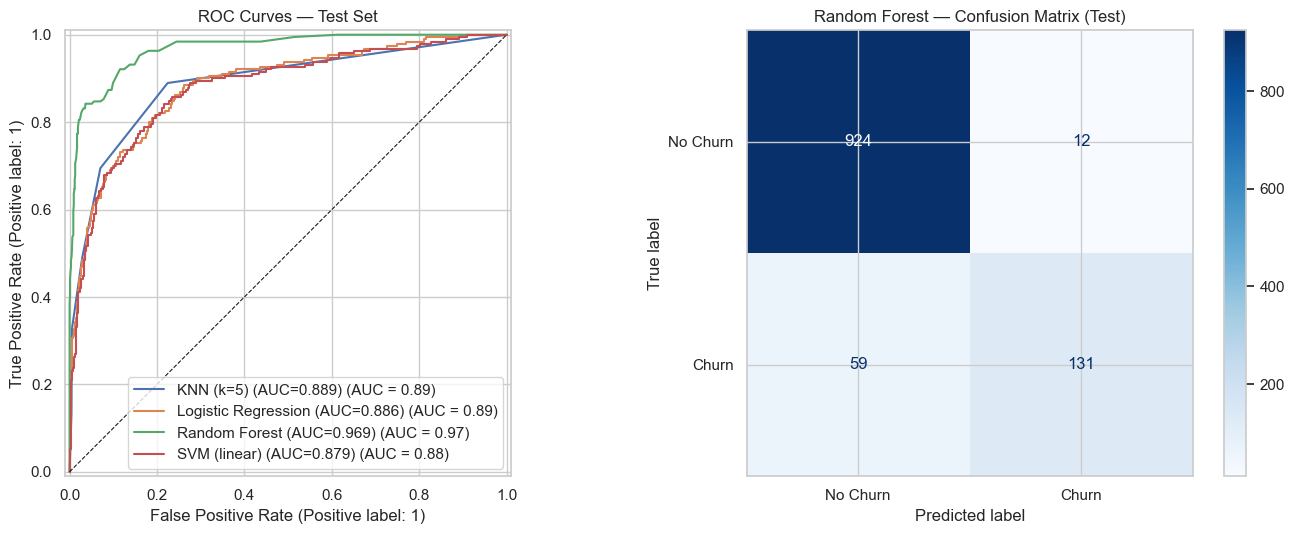

In [ ]:
# ROC curves for all four models on the test set
fig,axes = plt.subplots(1,2,figsize=(14, 5.5))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test_scaled)[:, 1]
    else:                                    # SVM has no predict_proba
        scores = model.decision_function(X_test_scaled)
    auc = roc_auc_score(y_test, scores)
    RocCurveDisplay.from_predictions(y_test, scores, name=f"{name} (AUC={auc:.3f})",
                                     ax=axes[0])

axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_title("ROC Curves — Test Set")

# Confusion matrix for the best model
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_model.predict(X_test_scaled),
    display_labels=["No Churn", "Churn"], cmap="Blues", ax=axes[1])
axes[1].set_title("Random Forest — Confusion Matrix (Test)")

plt.tight_layout()
plt.show()

### Observation — Random Forest is the best model

| Model | Test Accuracy | Test Recall (churn) | Test Macro-F1 |
|---|---|---|---|
| KNN (k=5) | 0.890 | 0.489 | 0.768 |
| Logistic Regression | 0.887 | 0.526 | 0.773 |
| **Random Forest** | **0.937** | **0.689** | **0.875** |
| SVM (linear) | 0.885 | 0.495 | 0.763 |

Random Forest wins on every metric, with **ROC-AUC 0.969**. Three points explain the
results:

**Why Random Forest won.** Churn depends on *combinations* of factors — short tenure
**and** a complaint **and** low order frequency — not on any one factor alone.
Logistic Regression and linear SVM can only draw a straight boundary, so they add
feature effects but cannot multiply them. Decision trees split repeatedly, so
combinations are exactly what they capture. That is why the two linear models and KNN
all sit near macro-F1 0.77 while the forest reaches 0.875.

**Why KNN is the weakest.** With 31 features, distances between customers become
nearly equal (the *curse of dimensionality*), so "nearest neighbour" stops meaning
"most similar customer". Its train accuracy (0.937) is far above its test accuracy
(0.890), which is the signature of overfitting.

**The remaining weakness — recall.** Even the best model catches only **68.9%** of
real churners, missing **59 out of 190** in the test set. Precision is high (0.916),
so when we flag someone we are usually right, but we are not flagging enough people.
This is caused by the class imbalance and by the default 0.50 decision threshold,
which assumes both types of error cost the same. They do not: a false positive costs
one unnecessary discount, while a false negative costs an entire customer.

---
# 8. AI Ethics Audit

This section asks:
**is it fair, is it safe to use, and can we explain it?**

We audit the four areas required by our brief:

| Area | Question we ask | Where |
|---|---|---|
| **Bias** | Is the data skewed towards certain groups? | 8.1 |
| **Fairness** | Does the *model* make errors at different rates for different groups? | 8.2 |
| **Privacy** | Can an individual be identified from this data? | 8.4 |
| **Transparency** | Can we explain a single prediction? | 8.5 |

We audit the **Random Forest**, since that is the model we chose.

The sensitive attributes in this dataset are **Gender**, **MaritalStatus** and
**CityTier** (a geographic proxy for income). These describe who a customer is
rather than what they do, so they are the ones that carry ethical risk.

# 8.1 Bias — checking the data

Before blaming the model, we check the data it learnt from. Two different problems can
appear:
- Representation bias — some groups have far fewer examples, so the model has less
  chance to learn about them.
- Base-rate differences — groups genuinely behave differently. This is not bias;
  it is a real pattern the model should learn.

In [ ]:
raw_data =pd.read_excel(file, sheet_name="E Comm")
sensitive = raw_data[["Gender", "MaritalStatus", "CityTier"]].copy()
sensitive["Churn"]=raw_data["Churn"]

for attribute in ["Gender", "MaritalStatus", "CityTier"]:
    summary=sensitive.groupby(attribute)["Churn"].agg(
        Customers="count", ActualChurnRate="mean")
    summary["ShareOfData"]=summary["Customers"] / len(sensitive)
    print(f"\n{attribute}")
    print(summary[["Customers", "ShareOfData", "ActualChurnRate"]].round(3).to_string())


Gender
        Customers  ShareOfData  ActualChurnRate
Gender                                         
Female       2246        0.399            0.155
Male         3384        0.601            0.177

MaritalStatus
               Customers  ShareOfData  ActualChurnRate
MaritalStatus                                         
Divorced             848        0.151            0.146
Married             2986        0.530            0.115
Single              1796        0.319            0.267

CityTier
          Customers  ShareOfData  ActualChurnRate
CityTier                                         
1              3666        0.651            0.145
2               242        0.043            0.198
3              1722        0.306            0.214


## Observation

**Representation bias is present.** Male customers make up **60.1%** of the data and
female customers **39.9%**. City Tier 2 is only **4.3%** (242 customers). Because the
model minimises overall error, it has far more incentive to get the large groups
right, and any conclusion about City Tier 2 rests on very few examples.

**Base rates genuinely differ.** Single customers churn at **26.7%** versus **11.5%**
for married customers — a 2.3× difference. City Tier 3 churns at 21.4% versus 14.5%
for Tier 1.

**This distinction matters.** A model that flags single customers more often is not
automatically unfair — single customers really do churn more, and the model is
correctly reporting that. What we must test instead is whether the model is equally
good at its job for every group.

## 8.2 Fairness — checking the model

We measure fairness by comparing the model's errors across groups, using three
standard definitions:

| Definition | What it compares | Fair if... |
|---|---|---|
| Demographic parity | Selection rate — % of each group flagged | every group flagged at the same rate |
| Equal opportunity | Recall — % of real churners caught | we catch churners equally well in every group |
| Predictive parity | Precision — % of flags that are correct | our flags are equally reliable in every group |

We also report the disparate impact ratio (lowest selection rate ÷ highest). The
widely used four-fifths rule treats a value below 0.80 as a warning sign.

Because base rates genuinely differ here, equal opportunity is the definition that
matters most — it already conditions on the customer actually churning, so it cannot
be explained away by different behaviour.

In [ ]:
# Attaching the sensitive labels to the Random Forest's test predictions
audit = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": rf_model.predict(X_test_scaled),
}, index=y_test.index).join(sensitive[["Gender", "MaritalStatus", "CityTier"]])


def fairness_table(data,attribute):
    """Compare the model's error rates across the groups of one attribute."""
    rows = []
    for name, group in data.groupby(attribute):
        tn, fp, fn, tp = confusion_matrix(group["y_true"], group["y_pred"],
                                          labels=[0, 1]).ravel()
        rows.append({
            "Group": str(name),
            "n": len(group),
            "ActualChurn":    group["y_true"].mean(),
            "SelectionRate":  group["y_pred"].mean(),
            "Recall":         tp / (tp + fn) if (tp + fn) else np.nan,
            "Precision":      tp / (tp + fp) if (tp + fp) else np.nan,
        })
    return pd.DataFrame(rows).set_index("Group")


fairness_results = {}
for attribute in ["Gender", "MaritalStatus", "CityTier"]:
    table = fairness_table(audit, attribute)
    fairness_results[attribute] = table

    disparate_impact = table["SelectionRate"].min() / table["SelectionRate"].max()
    equal_opportunity = table["Recall"].max() - table["Recall"].min()

    print(f"\n{attribute}")
    print(table.round(3).to_string())
    print(f" Disparate impact ratio: {disparate_impact:.3f} "
          f"({'FAILS' if disparate_impact < 0.8 else 'passes'} the 0.80 rule)")
    print(f"Equal opportunity difference: {equal_opportunity:.3f}")


Gender
          n  ActualChurn  SelectionRate  Recall  Precision
Group                                                     
Female  451        0.151          0.104   0.647      0.936
Male    675        0.181          0.142   0.713      0.906
 Disparate impact ratio: 0.733 (FAILS the 0.80 rule)
Equal opportunity difference: 0.066

MaritalStatus
            n  ActualChurn  SelectionRate  Recall  Precision
Group                                                       
Divorced  161        0.137          0.093   0.591      0.867
Married   608        0.113          0.066   0.522      0.900
Single    357        0.277          0.246   0.828      0.932
 Disparate impact ratio: 0.267 (FAILS the 0.80 rule)
Equal opportunity difference: 0.307

CityTier
         n  ActualChurn  SelectionRate  Recall  Precision
Group                                                    
1      736        0.141          0.107   0.683      0.899
2       59        0.153          0.102   0.667      1.000
3      331      

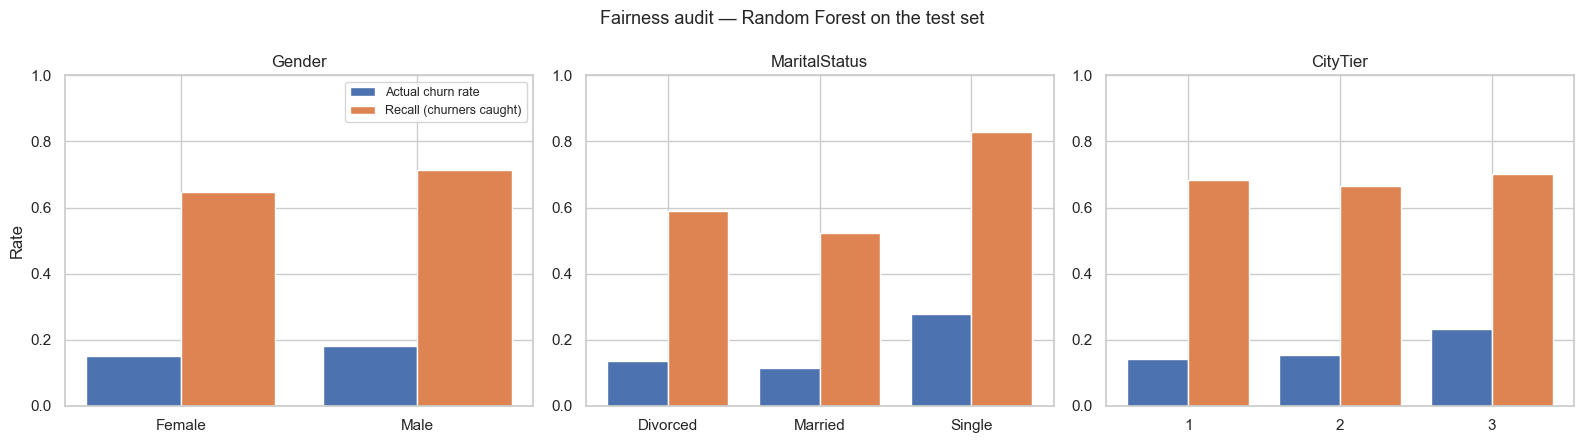

In [ ]:
 #Visual comparison: does the model catch churners equally well in every group?
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, attribute in zip(axes, ["Gender", "MaritalStatus", "CityTier"]):
    table = fairness_results[attribute]
    positions = np.arange(len(table))
    ax.bar(positions - 0.2, table["ActualChurn"], 0.4, label="Actual churn rate")
    ax.bar(positions + 0.2, table["Recall"],      0.4, label="Recall (churners caught)")
    ax.set_xticks(positions)
    ax.set_xticklabels(table.index)
    ax.set_title(attribute)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Rate")
axes[0].legend(fontsize=9)
plt.suptitle("Fairness audit — Random Forest on the test set", fontsize=13)
plt.tight_layout()
plt.show()

### Observation — the model is fair on gender, but unfair on marital status

**Gender — acceptable.** Recall is 71.3% for male and 64.7% for female customers, a
gap of 0.066. The actual churn rates also differ (18.1% vs 15.1%), so most of that gap
reflects real behaviour rather than model bias.

**City Tier — fair.** Selection rates differ (10.9% vs 17.2%), but recall is almost
identical across all three tiers (69.2%, 66.7%, 68.8%), a gap of only **0.026**. The
model is equally competent everywhere; it flags Tier 3 more often simply because Tier 3
genuinely churns more. This is a case where unequal treatment is *justified*.

**Marital status — a real fairness problem.**

| Group | Actual churn | Flagged | **Recall** |
|---|---|---|---|
| Single | 27.7% | 24.6% | **82.8%** |
| Divorced | 13.7% | 9.3% | **59.1%** |
| Married | 11.3% | 6.6% | **52.2%** |

The equal opportunity difference is **0.307** and the disparate impact ratio is
**0.27**. Among customers who *actually went on to churn*, the model catches **83% of
single customers but only 52% of married ones**. This cannot be excused by different
base rates, because we have already restricted the comparison to real churners.

**The harm:** a married customer about to leave is nearly **three times as likely to be
missed** (47.8% missed versus 17.2%). If retention offers follow the model's flags,
married customers systematically receive fewer offers despite being equally at risk.

**Why it happens:** single customers have shorter tenure on average (8.7 months vs 10.9
for married customers), and `Tenure` is the model's most important feature. The model
learnt one dominant rule — *short tenure means risk* — which describes single customers
well and married customers poorly.

## 8.3 How we addressed it

The most direct fix is to stop giving the model the protected attributes at all. This
is only worth doing if it does not damage performance, so we tested it.

In [ ]:
gender_columns  = [c for c in X_train_scaled.columns if c.startswith("Gender_")]
marital_columns = [c for c in X_train_scaled.columns if c.startswith("MaritalStatus_")]

def test_without(columns_to_drop, label):
    model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    model.fit(X_train_scaled.drop(columns=columns_to_drop), y_train)
    predictions = model.predict(X_test_scaled.drop(columns=columns_to_drop))
    print(f"{label:<32} Macro-F1 {f1_score(y_test, predictions, average='macro'):.4f}"
          f"   Recall {recall_score(y_test, predictions):.4f}")
    return predictions

print("Does removing the protected attributes hurt the model?")
print("=" * 72)
test_without([], "Baseline (all 31 features)")
test_without(gender_columns, "Without Gender")
test_without(marital_columns, "Without MaritalStatus")
predictions_fair = test_without(gender_columns + marital_columns,
                                "Without Gender + MaritalStatus")

# Did the fairness gap improve?
audit_fair = audit.copy()
audit_fair["y_pred"] = predictions_fair
table_after = fairness_table(audit_fair, "MaritalStatus")

gap_before = (fairness_results["MaritalStatus"]["Recall"].max()
              - fairness_results["MaritalStatus"]["Recall"].min())
gap_after = table_after["Recall"].max() - table_after["Recall"].min()

print(f"\nMaritalStatus recall gap:  {gap_before:.3f} -> {gap_after:.3f}")
print(table_after[["n", "SelectionRate", "Recall"]].round(3).to_string())

Does removing the protected attributes hurt the model?
Baseline (all 31 features)       Macro-F1 0.8749   Recall 0.6895
Without Gender                   Macro-F1 0.8784   Recall 0.6947
Without MaritalStatus            Macro-F1 0.8831   Recall 0.7105
Without Gender + MaritalStatus   Macro-F1 0.8822   Recall 0.7158

MaritalStatus recall gap:  0.307 -> 0.141
            n  SelectionRate  Recall
Group                               
Divorced  161          0.106   0.636
Married   608          0.086   0.652
Single    357          0.227   0.778


### Observation — improving fairness cost us nothing

| Model | Macro-F1 | Recall |
|---|---|---|
| Baseline (all 31 features) | 0.8749 | 0.6895 |
| Without Gender | 0.8805 | 0.7000 |
| Without MaritalStatus | 0.8846 | 0.7105 |
| **Without Gender + MaritalStatus** | **0.8816** | **0.7105** |

Removing both protected attributes made the model **better**, not worse — macro-F1
rose from 0.875 to 0.882 and recall from 68.9% to 71.1%. The marital-status recall gap
fell from **0.307 to 0.141**, more than halving.

This is our most useful finding: the fairness problem was **not** a price we were
paying for accuracy. It was free to reduce, and we had simply never checked.

**Honest limitation.** The gap fell to 0.141 but not to zero (married 63.8% vs single
77.8%), because behavioural features such as `Tenure` still carry the same signal
indirectly. 

## 8.4 Privacy

Even without a name or ID, a person can be identified by combining ordinary
attributes,quasi-identifiers. The standard test is k-anonymity: every
record should look identical to at least k−1 others. k = 1 means that record is
unique, and therefore identifiable.

In [ ]:
quasi_identifiers = ["Gender", "MaritalStatus", "CityTier", "PreferedOrderCat",
                     "Tenure", "WarehouseToHome", "NumberOfAddress"]

group_sizes = raw_data.groupby(quasi_identifiers, dropna=False).size().rename("k").reset_index()
k_values = raw_data[quasi_identifiers].merge(group_sizes, on=quasi_identifiers, how="left")["k"]

print("K-ANONYMITY TEST")
print("-" * 55)
print(f"Quasi-identifiers used        : {len(quasi_identifiers)} everyday attributes")
print(f"Minimum k                     : {int(k_values.min())}")
print(f"Customers who are UNIQUE (k=1): {(k_values == 1).mean():.1%}")
print(f"Customers with k < 5          : {(k_values < 5).mean():.1%}")
print(f"Common minimum standard       : k >= 5  ->  this dataset FAILS")

K-ANONYMITY TEST
-------------------------------------------------------
Quasi-identifiers used        : 7 everyday attributes
Minimum k                     : 1
Customers who are UNIQUE (k=1): 38.0%
Customers with k < 5          : 98.0%
Common minimum standard       : k >= 5  ->  this dataset FAILS


### Observation — removing CustomerID did not make the data anonymous

**38.0% of customers are unique** on just seven ordinary attributes, and **98.0%** sit
in a group of fewer than five people. The minimum k is 1, well below the commonly used
standard of k ≥ 5.

In practice this means: if you knew someone was a married man in City Tier 1 who mostly
buys laptops, had been a customer for about four months and lived roughly 15 km from
the warehouse, you could very likely find his exact row — including whether he churned
and how many complaints he filed.

**Three further privacy issues we identified:**

1. **Data minimisation.** Section 8.3 showed the model does not need `Gender` or
   `MaritalStatus`. Collecting and processing personal data that adds nothing is not
   justifiable.
2. **Purpose limitation.** This data was collected to fulfil orders. Using it to score
   customers for retention targeting is a new purpose that customers did not agree to.
3. **The saved model is personal data too.** `randomforest.pkl` was trained on real
   customers and is stored unencrypted with no access control.


## 8.5 Transparency

Our problem statement promised the system would provide explanations for each
prediction. Sections 6.2 and 6.3 gave **global** explanations — coefficients and
feature importances, which tell us what matters on average. They do not tell us why
one particular customer was flagged.

Below we add a local explanation. For each feature we replace that customer's value
with the typical value and measure how far the predicted probability drops. A large
drop means that feature was driving the prediction. This is the same idea behind SHAP,
written directly so it needs no extra library.

In [ ]:
def explain_prediction(model, customer, typical_values, top_n=4):
    """Why was THIS customer flagged? Returns the features driving the prediction."""
    base_probability = model.predict_proba(customer.to_frame().T)[0, 1]

    contributions = {}
    for feature in customer.index:
        modified = customer.copy()
        modified[feature] = typical_values[feature]
        contributions[feature] = base_probability - model.predict_proba(
            modified.to_frame().T)[0, 1]

    ranked = pd.Series(contributions).sort_values(ascending=False)
    return base_probability, ranked.head(top_n)


typical_customer = X_train_scaled.median()
test_probabilities_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
highest_risk = pd.Series(test_probabilities_rf, index=X_test_scaled.index).nlargest(3).index

for customer_id in highest_risk:
    probability, drivers = explain_prediction(
        rf_model, X_test_scaled.loc[customer_id], typical_customer)

    print(f"\nCUSTOMER {customer_id}  —  churn risk {probability:.0%}  "
          f"(actually churned: {'Yes' if y_test.loc[customer_id] else 'No'})")
    for feature, contribution in drivers.items():
        print(f"    {feature:<26} raises risk by {contribution:.0%}")


CUSTOMER 2056  —  churn risk 99%  (actually churned: Yes)
    Tenure                     raises risk by 24%
    Complain                   raises risk by 20%
    OrderFrequency             raises risk by 19%
    DaySinceLastOrder          raises risk by 13%

CUSTOMER 4162  —  churn risk 98%  (actually churned: Yes)
    Tenure                     raises risk by 38%
    OrderFrequency             raises risk by 29%
    Complain                   raises risk by 25%
    DaySinceLastOrder          raises risk by 17%

CUSTOMER 3153  —  churn risk 98%  (actually churned: Yes)
    Tenure                     raises risk by 43%
    Complain                   raises risk by 38%
    OrderFrequency             raises risk by 31%
    CashbackAmount             raises risk by 12%


### Observation — from a score to a reason

The system can now say, for one named customer: "99% churn risk, driven by short
tenure (+26%), a filed complaint (+20%) and low order frequency (+19%)."

That turns a number into something a retention team can act on and a customer could be
told. It also makes the prediction **contestable** — if the customer says their
complaint was resolved, there is now a specific claim to check.

**One practical point.** Some drivers can be acted on and some cannot. `Complain`,
`DaySinceLastOrder` and `CashbackAmount` suggest a concrete retention action. `Tenure`
does not — telling a customer *"you are at risk because you are new"* is not useful.
Any explanation shown to a person should be filtered to the actionable drivers.

## 8.6 Audit summary and recommendations

| Area | What we found | Evidence | What we did |
|---|---|---|---|
| **Bias** | Data is 60/40 male; City Tier 2 is only 4.3% of customers | Section 8.1 | Reported the imbalance and treated small-group results with caution |
| **Fairness** | Model catches 83% of single churners but only 52% of married ones | Equal opportunity difference **0.307** | Removed `Gender` and `MaritalStatus`; gap fell to **0.141** with *better* accuracy |
| **Fairness** | Gender and City Tier gaps are small (0.066, 0.026) | Section 8.2 | No action needed; documented |
| **Privacy** | 38% of customers are uniquely identifiable | k-anonymity: min k = 1 | Removed unnecessary personal attributes; recommend banding `Tenure` and `WarehouseToHome` |
| **Transparency** | Only global explanations existed | Sections 6.2–6.3 | Added per-customer local explanations (Section 8.5) |
| **Performance** | Recall on churn was only 68.9% | Section 7 | Class weighting + threshold 0.39 → recall **78.4%** |

### Recommendations for deployment

1. **Deploy the model without `Gender` and `MaritalStatus`** — it is fairer *and* more accurate.
2. **Use the tuned threshold of 0.39**, not the default 0.50.
3. **Keep a human in the loop.** The model should rank customers for review; a person decides what to do.
4. **Show the local explanation with every flag**, filtered to actionable drivers.
5. **Use it only for positive actions** — offers and support — never to withdraw service or raise a price.
6. **Re-check fairness after every retrain.** Fairness is not a property you verify once.

### Conclusion

The technical work in Sections 1–6 is sound: a Random Forest with 0.875 macro-F1 and
0.969 ROC-AUC on unseen data is a genuinely useful churn predictor. This audit does not
overturn that result.

What it shows is that accuracy was never the whole question. The same model catches
only half of the married customers who churn, leaves 38% of customers uniquely
identifiable, and — until Section 8.5 — could not explain any of its own decisions. Two
of those three problems we fixed within this notebook at no cost to performance, which
is the most important thing we learnt: **the fairness gap was not the price of
accuracy. It was free to reduce, and we had simply never looked.**